# Genetic Optimization (GO)

## Overview

![Overview](../figures/go_overview.png)

GO is a population-based heuristic. Each generation:
1. **Select** two parents from the population (rank-based, biased toward better solutions)
2. **Crossover** — combine their genes to form a child
3. **Mutate** — apply a small perturbation to the child
4. **Select survivors** from the working population to form the next generation

Key parameters: population size $N$, working population size $M > N$, selection temperatures $T_{sel1}$ (parent selection) and $T_{sel2}$ (survivor selection).

In [1]:
# Import path to source directory (bit of a hack in Jupyter)
import sys
import os
pwd = %pwd
sys.path.append(os.path.join(pwd, '..', 'src'))

%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from heur_go import GeneticOptimization, Crossover, UniformMultipoint, RandomCombination
from heur_aux import CauchyMutation, MirrorCorrection
from objfun_rastrigin import Rastrigin

## Building blocks

### 1. Selection

Parents and survivors are chosen by **rank-based selection** using an exponential distribution.
Given a sorted population (best first) and selection temperature $T$:

$$R = \left\lceil \frac{-T \ln U}{1} \right\rceil$$

where $U \sim \text{Uniform}(0, 1)$ and $R$ is the (1-based) rank of the selected individual.

Low $T$ → nearly always picks rank 1 (greedy). High $T$ → flat distribution (random).

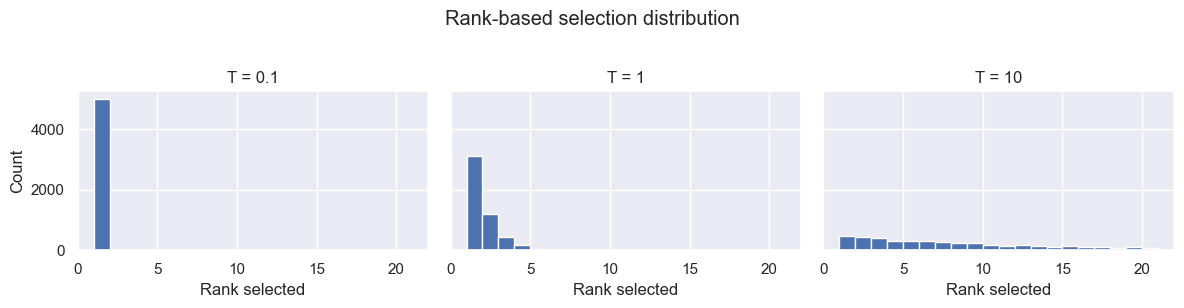

In [3]:
rng_demo = np.random.default_rng(42)
u = rng_demo.uniform(size=5000)

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for ax, T in zip(axes, [0.1, 1, 10]):
    ranks = np.ceil(-T * np.log(u))
    ax.hist(ranks[ranks <= 20], bins=range(1, 22), edgecolor='white')
    ax.set_title(f'T = {T}')
    ax.set_xlabel('Rank selected')
axes[0].set_ylabel('Count')
plt.suptitle('Rank-based selection distribution', y=1.02)
plt.tight_layout()

### 2. Crossover

Three operators are available. Given parents `x` (all 0s) and `y` (all 9s) for illustration:

In [4]:
rng_demo = np.random.default_rng(0)
x = np.zeros(10, dtype=int)
y = 9 * np.ones(10, dtype=int)

print('Parents:              x =', x)
print('                      y =', y)
print()
print('Crossover (random mix):    ', Crossover().crossover(x, y, rng_demo))
print('UniformMultipoint(4):      ', UniformMultipoint(4).crossover(x, y, rng_demo))
print('RandomCombination:         ', RandomCombination().crossover(x, y, rng_demo))

Parents:              x = [0 0 0 0 0 0 0 0 0 0]
                      y = [9 9 9 9 9 9 9 9 9 9]

Crossover (random mix):     [9 0 0 0 9 9 9 9 9 9]
UniformMultipoint(4):       [0 0 9 9 0 0 9 9 0 0]
RandomCombination:          [2 8 6 0 3 8 5 0 7 7]


- **`Crossover`** (random mix): each gene independently drawn from one parent at random.
- **`UniformMultipoint(n)`**: alternating blocks of length $\lceil d/n \rceil$ taken from each parent.
- **`RandomCombination`**: each gene is a random value *between* the two parents — the only operator that can produce values not present in either parent. Most natural for continuous domains.

### 3. Mutation

We reuse `CauchyMutation` from the FSA toolbox. In the GO context it plays a secondary role — crossover handles global recombination, mutation adds local diversity. The mutation width `r` should therefore be smaller than in FSA.

## Objective function: Rastrigin (2D)

$$f(x_1, x_2) = 20 + x_1^2 + x_2^2 - 10(\cos 2\pi x_1 + \cos 2\pi x_2)$$

Global minimum $f^* = 0$ at $(0, 0)$. The landscape has a regular grid of local minima at integer coordinates — a direct test of the algorithm's ability to escape traps.

In [5]:
of = Rastrigin(n=2, eps=0.5)
print(f'Domain : [{of.a[0]}, {of.b[0]}]^2')
print(f'f*     : {of.fstar}  (success = f(x) ≤ {of.fstar})')
print()
print('Note: the nearest local minima have f≈1, so eps=0.5 means')
print('the algorithm must reach the global basin, not just any local minimum.')

Domain : [-5.12, 5.12]^2
f*     : 0.5  (success = f(x) ≤ 0.5)

Note: the nearest local minima have f≈1, so eps=0.5 means
the algorithm must reach the global basin, not just any local minimum.


### Experiment setup

Unified experiment runner and stats computer, consistent with the FSA scaling notebook.

In [6]:
def experiment_go(of, maxeval, num_runs, N, M, Tsel1, Tsel2, mutation, crossover, label):
    results = []
    for i in tqdm(range(num_runs), desc=f'Testing {label}'):
        result = GeneticOptimization(
            of, maxeval, N=N, M=M, Tsel1=Tsel1, Tsel2=Tsel2,
            mutation=mutation, crossover=crossover, seed=i
        ).search()
        result['run'] = i
        result['heur'] = label
        results.append(result)
    return pd.DataFrame(results, columns=['heur', 'run', 'best_x', 'best_y', 'neval', 'success'])


def compute_stats(table, group_by='heur'):
    def agg(g):
        rel = g['success'].mean()
        successful = g.loc[g['success'], 'neval']
        mne = successful.mean() if len(successful) > 0 else np.nan
        feo = mne / rel if (rel > 0 and not np.isnan(mne)) else np.nan
        return pd.Series({'rel': rel, 'mne': mne, 'feo': feo})
    return table.groupby(group_by)[['neval', 'success']].apply(agg).reset_index()


NUM_RUNS = 1_000
MAXEVAL  = 5_000

## Parameter sweep: population size $N$

Using `RandomCombination` (most natural for continuous domains) and $M = 3N$.
Varying $N$ from 1 (effectively a single-solution hill-climber) to 50.

In [7]:
table_N = pd.DataFrame()

for N in [1, 2, 5, 10, 20, 50, 100]:
    res = experiment_go(
        of=of, maxeval=MAXEVAL, num_runs=NUM_RUNS,
        N=N, M=N * 3, Tsel1=1.0, Tsel2=0.1,
        mutation=CauchyMutation(r=0.5, correction=MirrorCorrection(of)),
        crossover=RandomCombination(),
        label=f'GO_N{N}'
    )
    res['N'] = N
    table_N = pd.concat([table_N, res], ignore_index=True)

Testing GO_N1:   0%|          | 0/1000 [00:00<?, ?it/s]

Testing GO_N2:   0%|          | 0/1000 [00:00<?, ?it/s]

Testing GO_N5:   0%|          | 0/1000 [00:00<?, ?it/s]

Testing GO_N10:   0%|          | 0/1000 [00:00<?, ?it/s]

Testing GO_N20:   0%|          | 0/1000 [00:00<?, ?it/s]

Testing GO_N50:   0%|          | 0/1000 [00:00<?, ?it/s]

Testing GO_N100:   0%|          | 0/1000 [00:00<?, ?it/s]

  N    heur   rel         mne         feo
  1   GO_N1 0.720 1947.738889 2705.192901
  2   GO_N2 0.888 1681.931306 1894.066786
  5   GO_N5 0.957 1314.303030 1373.357398
 10  GO_N10 0.987 1177.937183 1193.452060
 20  GO_N20 0.996  975.299197  979.216061
 50  GO_N50 1.000  910.573000  910.573000
100 GO_N100 0.999  950.519520  951.470991


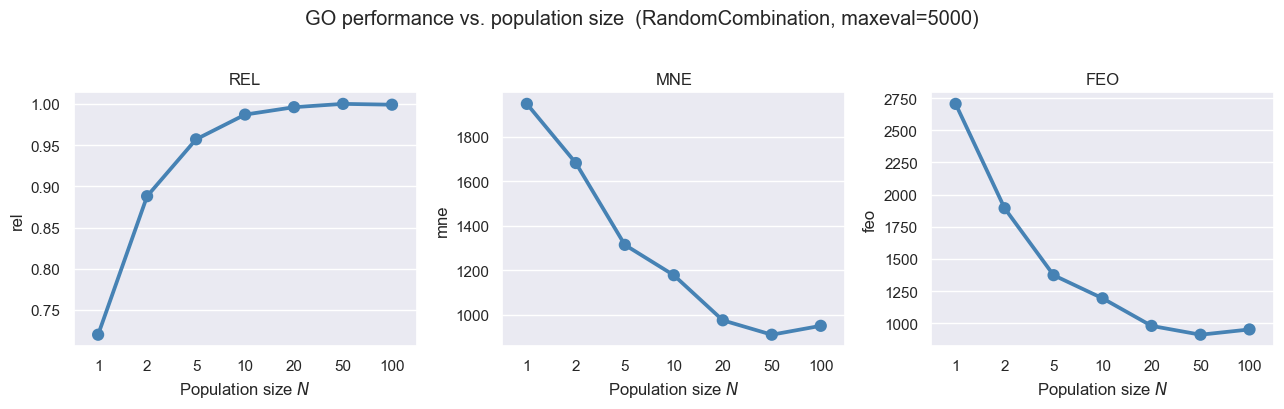

In [8]:
stats_N = compute_stats(table_N, group_by=['N', 'heur'])
print(stats_N.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric in zip(axes, ['rel', 'mne', 'feo']):
    sns.pointplot(data=stats_N, x='N', y=metric, ax=ax, color='steelblue')
    ax.set_title(metric.upper())
    ax.set_xlabel('Population size $N$')
plt.suptitle('GO performance vs. population size  (RandomCombination, maxeval=5000)', y=1.02)
plt.tight_layout()

$N=50$ could be the sweet spot in this case.

## Parameter sweep: crossover operator

Fixing $N$ at the sweet spot found above and comparing all four crossover operators.

In [9]:
BEST_N = 50

crossovers = [
    ('mix',  Crossover()),
    ('uni1', UniformMultipoint(1)),
    ('uni2', UniformMultipoint(2)),
    ('rnd',  RandomCombination()),
]

table_co = pd.DataFrame()

for co_name, co in crossovers:
    res = experiment_go(
        of=of, maxeval=MAXEVAL, num_runs=NUM_RUNS,
        N=BEST_N, M=BEST_N * 3, Tsel1=1.0, Tsel2=0.1,
        mutation=CauchyMutation(r=0.5, correction=MirrorCorrection(of)),
        crossover=co,
        label=f'GO_{co_name}'
    )
    table_co = pd.concat([table_co, res], ignore_index=True)

Testing GO_mix:   0%|          | 0/1000 [00:00<?, ?it/s]

Testing GO_uni1:   0%|          | 0/1000 [00:00<?, ?it/s]

Testing GO_uni2:   0%|          | 0/1000 [00:00<?, ?it/s]

Testing GO_rnd:   0%|          | 0/1000 [00:00<?, ?it/s]

In [10]:
stats_co = compute_stats(table_co)
stats_co

,heur,rel,mne,feo
0,GO_mix,0.998,1005.120240,1007.134509
1,GO_rnd,1.000,910.573000,910.573000
2,GO_uni1,0.996,1012.656627,1016.723521
3,GO_uni2,0.996,1012.656627,1016.723521


## Conclusion

### Population size

Very small $N$ (1–2) leaves GO behaving like a restartable hill-climber — no population diversity to exploit, and success rates drop to near zero. Larger populations provide the diversity needed to escape local minima via crossover. However, very large $N$ dilutes the evaluation budget across too many individuals per generation, reducing the number of generations and the chance of convergence. The sweet spot on this landscape is typically around $N \approx 5$–$20$.

### Crossover operator

On a multimodal landscape like Rastrigin, **random mix** (`Crossover`) tends to perform best or on par with the alternatives. `RandomCombination` interpolates between parents, which is efficient when parents are already close to the optimum — but if both parents are trapped in different local minima, interpolation may land in a valley rather than a peak. Block-based `UniformMultipoint` operators preserve larger contiguous segments from each parent, which can be beneficial or harmful depending on the structure of the landscape.

### Assignment

* How does GO scale with dimension? Repeat the experiments on `Rastrigin(n=5)` — does the sweet spot for $N$ shift?
* Try `MirrorCorrection` vs `ExtensionCorrection` for mutation — does the boundary-handling strategy affect performance on this domain?